# GSK_HepG2 ablation: metric vs deltaprop candidate-pool size

Pulls the single run from the `ablation_gsk_hepg2_candidates` wandb project, recovers the per-(candidate_size, model) rows from its history, and plots deltaprop across candidate sizes with the chemprop baseline as a horizontal reference line.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and split on the `model` column ourselves. chemprop is invariant to `candidate_size`, so it appears once with `candidate_size = NaN`.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation_gsk_hepg2_candidates"
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_roc_auc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
# assert len(runs) == 1, f"expected a single run, found {len(runs)}"
runs = [r for r in runs]
print(runs)
run = runs[0]
run.name, run.id

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/rahul/.netrc.


[<Run rahul-e-dev/ablation_gsk_hepg2_candidates/4zevl8hy (finished)>]


('avid-feather-6', '4zevl8hy')

In [2]:
# Full, unsampled history -> one row per (candidate_size, model).
df = pd.DataFrame(run.scan_history())
df = df[["candidate_size", "model", "n_train", METRIC]].sort_values(["model", "candidate_size"])
df

,candidate_size,model,n_train,test_average_precision
0,NaN,chemprop,4212,0.372939
1,2.0,deltaprop,4212,0.396469
2,4.0,deltaprop,4212,0.431524
3,8.0,deltaprop,4212,0.380839
4,16.0,deltaprop,4212,0.387727
5,24.0,deltaprop,4212,0.419353
6,32.0,deltaprop,4212,0.362683
7,40.0,deltaprop,4212,0.395809
8,48.0,deltaprop,4212,0.397329


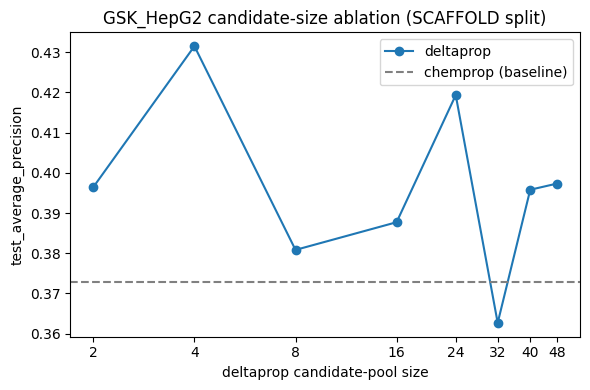

In [3]:
delta = df[df["model"] == "deltaprop"].sort_values("candidate_size")
chemprop = df[df["model"] == "chemprop"]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(delta["candidate_size"], delta[METRIC], marker="o", label="deltaprop")

if len(chemprop):
    ax.axhline(
        chemprop[METRIC].iloc[0],
        color="gray",
        linestyle="--",
        label="chemprop (baseline)",
    )

ax.set_xscale("log", base=2)
ax.set_xticks(delta["candidate_size"])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("deltaprop candidate-pool size")
ax.set_ylabel(METRIC)
ax.set_title("GSK_HepG2 candidate-size ablation (SCAFFOLD split)")
ax.legend()
fig.tight_layout()
fig.savefig("gsk_hepg2_candidates_ablation.png", dpi=150)
plt.show()